# Sistem Rekomendasi Varietas Tanaman Hortikultura (Revamped)
**Algoritma:** Random Forest Classifier  
**Objektif:** Merekomendasikan varietas tanaman hortikultura terbaik berdasarkan analisis geografis makro (klasifikasi kecamatan) dan kemiripan kondisi lingkungan (pH Tanah, Suhu, Curah Hujan, Elevasi).

---
## 9 Tahapan Alur Machine Learning:
1. **Pemisahan Fitur & Target**
2. **Imputasi Nilai Hilang (Missing Value Imputation)**
3. **Encoding Data Kategorikal**
4. **Encoding Target**
5. **Split Data Train-Test (80/20 Stratified)**
6. **Pelatihan Model Random Forest**
7. **Evaluasi & Classification Report**
8. **Uji Stabilitas (Stratified K-Fold Cross Validation)**
9. **Feature Importance & Simulasi Prediksi**

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Set style untuk visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load Dataset

In [2]:
# Load dataset baru hasil generasi di folder data2/
data_path = 'data2/dataset_training_random_forest_generated.csv'
df_raw = pd.read_csv(data_path)
print(f"Total Baris Data: {len(df_raw)} baris")
df_raw.head()

Total Baris Data: 4050 baris


,Nama_Tanaman,Kecamatan,pH_Tanah,Suhu_C,Curah_Hujan_mm,Elevasi_mdpl,Nama_Varietas
0,Ketimun,Baktiya,5.44,27.0,2123.0,34.2,Hercules F1
1,Ketimun,Baktiya,5.33,26.9,2169.6,22.9,Hercules F1
2,Ketimun,Baktiya,5.30,27.1,2067.4,4.4,Hercules F1
3,Ketimun,Baktiya,5.41,26.5,2004.4,3.0,Hercules F1
4,Ketimun,Baktiya,5.22,27.1,2045.2,0.0,Hercules F1


## 3. Tahap 1 & 2: Imputasi Nilai Hilang & Pemisahan Fitur-Target

In [3]:
df = df_raw.copy()

# A. Cek Nilai Hilang (Missing Values)
print("Cek nilai hilang sebelum imputasi:")
print(df.isnull().sum())

# B. Melakukan Imputasi Median Global pada kolom Suhu_C
missing_suhu = df['Suhu_C'].isnull().sum()
if missing_suhu > 0:
    suhu_median = df['Suhu_C'].median()
    print(f"\n[IMPUTASI] Mengisi {missing_suhu} data kosong pada 'Suhu_C' dengan median: {suhu_median:.2f}°C")
    df['Suhu_C'] = df['Suhu_C'].fillna(suhu_median)

print("\nCek nilai hilang setelah imputasi:")
print(df.isnull().sum())

Cek nilai hilang sebelum imputasi:
Nama_Tanaman      0
Kecamatan         0
pH_Tanah          0
Suhu_C            0
Curah_Hujan_mm    0
Elevasi_mdpl      0
Nama_Varietas     0
dtype: int64

Cek nilai hilang setelah imputasi:
Nama_Tanaman      0
Kecamatan         0
pH_Tanah          0
Suhu_C            0
Curah_Hujan_mm    0
Elevasi_mdpl      0
Nama_Varietas     0
dtype: int64


## 4. Tahap 3 & 4: Encoding Data Kategorikal & Encoding Target

In [4]:
# A. Label Encoding untuk Target Kecamatan
print("Melakukan Label Encoding pada Target 'Kecamatan'...")
le_kecamatan = LabelEncoder()
df['Kecamatan_Encoded'] = le_kecamatan.fit_transform(df['Kecamatan'])

# B. Label Encoding Tambahan untuk Nama_Tanaman dan Nama_Varietas
le_tanaman = LabelEncoder()
df['Nama_Tanaman_Encoded'] = le_tanaman.fit_transform(df['Nama_Tanaman'])

le_varietas = LabelEncoder()
df['Nama_Varietas_Encoded'] = le_varietas.fit_transform(df['Nama_Varietas'])

# Simpan encoder ke folder models/
os.makedirs('models', exist_ok=True)
joblib.dump(le_kecamatan, 'models/le_kecamatan.joblib')
joblib.dump(le_tanaman, 'models/le_tanaman.joblib')
joblib.dump(le_varietas, 'models/le_varietas.joblib')
print("Semua encoder berhasil disimpan ke folder 'models/'")

# Simpan dataset preprocessed
os.makedirs('data2', exist_ok=True)
df.to_csv('data2/processed_dataset.csv', index=False)
print("Dataset preprocessed berhasil disimpan ke 'data2/processed_dataset.csv'")

Melakukan Label Encoding pada Target 'Kecamatan'...
Semua encoder berhasil disimpan ke folder 'models/'
Dataset preprocessed berhasil disimpan ke 'data2/processed_dataset.csv'


## 5. Tahap 5: Split Data Train-Test (80/20 Stratified)

In [5]:
# Tentukan Fitur Lingkungan (X) dan Target Lokasi (y)
feature_names = ['pH_Tanah', 'Suhu_C', 'Curah_Hujan_mm', 'Elevasi_mdpl']
X = df[feature_names]
y = df['Kecamatan_Encoded']

# Lakukan Stratified Split untuk menjaga keseimbangan persebaran data tiap Kecamatan
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Jumlah Data Training : {len(X_train)} baris")
print(f"Jumlah Data Testing  : {len(X_test)} baris")

Jumlah Data Training : 3240 baris
Jumlah Data Testing  : 810 baris


## 6. Tahap 6: Pelatihan Model Random Forest

In [6]:
print("Melatih model Random Forest Classifier dengan 100 pohon...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Simpan model hasil training
joblib.dump(rf_model, 'models/random_forest_model.joblib')
print("Model berhasil dilatih dan disimpan ke 'models/random_forest_model.joblib'!")

Melatih model Random Forest Classifier dengan 100 pohon...
Model berhasil dilatih dan disimpan ke 'models/random_forest_model.joblib'!


## 7. Tahap 7: Evaluasi & Classification Report

In [7]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi Model Klasifikasi Kecamatan: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_kecamatan.classes_))

Akurasi Model Klasifikasi Kecamatan: 55.93%

Classification Report:
                 precision    recall  f1-score   support

        Baktiya       0.42      0.47      0.44        30
  Baktiya Barat       0.29      0.33      0.31        30
     Banda Baro       0.46      0.40      0.43        30
      Cot Girek       0.89      0.83      0.86        30
      Dewantara       0.41      0.30      0.35        30
Geureudong Pase       0.97      1.00      0.98        30
    Kuta Makmur       0.89      0.80      0.84        30
      Langkahan       0.87      0.87      0.87        30
         Lapang       0.39      0.50      0.44        30
      Lhoksukon       0.30      0.33      0.32        30
     Matangkuli       0.27      0.23      0.25        30
   Meurah Mulia       0.32      0.23      0.27        30
     Muara Batu       0.27      0.23      0.25        30
         Nibong       0.24      0.27      0.25        30
          Nisam       0.38      0.33      0.36        30
   Nisam Antara    

## 8. Tahap 8: Uji Stabilitas Model dengan Stratified K-Fold Cross Validation
Untuk memastikan akurasi model stabil di seluruh lipatan data (*folds*) dan menghindari bias dari pembagian data *train-test*, dilakukan pengujian menggunakan **5-Fold Stratified Cross Validation**.

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Inisialisasi Stratified K-Fold (5 Lipatan)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Hitung Akurasi untuk Setiap Fold
print("--- Melakukan 5-Fold Stratified Cross Validation ---")
scores = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

# 3. Tampilkan Hasil Analisis Lipatan
for fold, score in enumerate(scores):
    print(f"Fold {fold+1} Accuracy: {score * 100:.2f}%")

print("-" * 50)
print(f"Rata-rata Akurasi (Mean) : {scores.mean() * 100:.2f}%")
print(f"Standar Deviasi (Std Dev): {scores.std() * 100:.4f}")

--- Melakukan 5-Fold Stratified Cross Validation ---
Fold 1 Accuracy: 55.43%
Fold 2 Accuracy: 54.94%
Fold 3 Accuracy: 53.70%
Fold 4 Accuracy: 53.46%
Fold 5 Accuracy: 55.93%
--------------------------------------------------
Rata-rata Akurasi (Mean) : 54.69%
Standar Deviasi (Std Dev): 0.9626


### Tuning Hyperparameter dengan RandomizedSearchCV
Untuk meningkatkan performa model, kita melakukan tuning hyperparameter menggunakan `RandomizedSearchCV` untuk mengeksplorasi ruang parameter secara efisien.

In [9]:
from sklearn.model_selection import RandomizedSearchCV
import time

# Ruang pencarian hyperparameter
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

skf_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=40,              # jumlah kombinasi yang dicoba
    cv=skf_tune,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Menjalankan Randomized Search (40 kombinasi x 5-fold)...")
start = time.time()
random_search.fit(X_train, y_train)
print(f"Selesai dalam {time.time()-start:.1f} detik")

print("\nParameter terbaik:")
print(random_search.best_params_)
print(f"\nAkurasi CV terbaik: {random_search.best_score_*100:.2f}%")

Menjalankan Randomized Search (40 kombinasi x 5-fold)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Selesai dalam 42.4 detik

Parameter terbaik:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced'}

Akurasi CV terbaik: 57.01%


### Refit Model Terbaik dan Perbandingan dengan Baseline

In [10]:
# Model tuned pakai parameter terbaik
rf_tuned = random_search.best_estimator_

y_pred_tuned = rf_tuned.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print("="*60)
print("PERBANDINGAN BASELINE vs TUNED")
print("="*60)
print(f"Baseline (default)  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Tuned (best params)  : {acc_tuned:.4f} ({acc_tuned*100:.2f}%)")
print(f"Selisih              : {(acc_tuned-accuracy)*100:+.2f} poin persen")
print("="*60)

print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned, target_names=le_kecamatan.classes_))

PERBANDINGAN BASELINE vs TUNED
Baseline (default)  : 0.5593 (55.93%)
Tuned (best params)  : 0.5790 (57.90%)
Selisih              : +1.98 poin persen

Classification Report (Tuned Model):
                 precision    recall  f1-score   support

        Baktiya       0.56      0.50      0.53        30
  Baktiya Barat       0.38      0.50      0.43        30
     Banda Baro       0.44      0.37      0.40        30
      Cot Girek       0.93      0.87      0.90        30
      Dewantara       0.52      0.43      0.47        30
Geureudong Pase       0.97      1.00      0.98        30
    Kuta Makmur       0.89      0.83      0.86        30
      Langkahan       0.90      0.90      0.90        30
         Lapang       0.35      0.40      0.38        30
      Lhoksukon       0.33      0.27      0.30        30
     Matangkuli       0.27      0.10      0.15        30
   Meurah Mulia       0.36      0.53      0.43        30
     Muara Batu       0.36      0.17      0.23        30
         Nibon

### Validasi Ulang Model Tuned dengan 5-Fold Cross Validation
Kita memvalidasi stabilitas model yang telah di-tune untuk mendeteksi tanda-tanda overfitting.

In [11]:
scores_tuned = cross_val_score(rf_tuned, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

print("--- 5-Fold CV: Model Tuned ---")
for fold, score in enumerate(scores_tuned):
    print(f"Fold {fold+1} Accuracy: {score * 100:.2f}%")
print("-" * 50)
print(f"Rata-rata Akurasi (Mean) : {scores_tuned.mean() * 100:.2f}%")
print(f"Standar Deviasi (Std Dev): {scores_tuned.std() * 100:.4f}")

# Kalau tuned CV mean jauh lebih tinggi dari test accuracy tapi std naik drastis,
# itu tanda overfitting ke fold tertentu — waspadai

--- 5-Fold CV: Model Tuned ---
Fold 1 Accuracy: 58.15%
Fold 2 Accuracy: 58.02%
Fold 3 Accuracy: 55.19%
Fold 4 Accuracy: 57.04%
Fold 5 Accuracy: 57.53%
--------------------------------------------------
Rata-rata Akurasi (Mean) : 57.19%
Standar Deviasi (Std Dev): 1.0746


## 9. Tahap 9: Feature Importance & Simulasi Prediksi

### A. Visualisasi Kontribusi Fitur (Feature Importance)

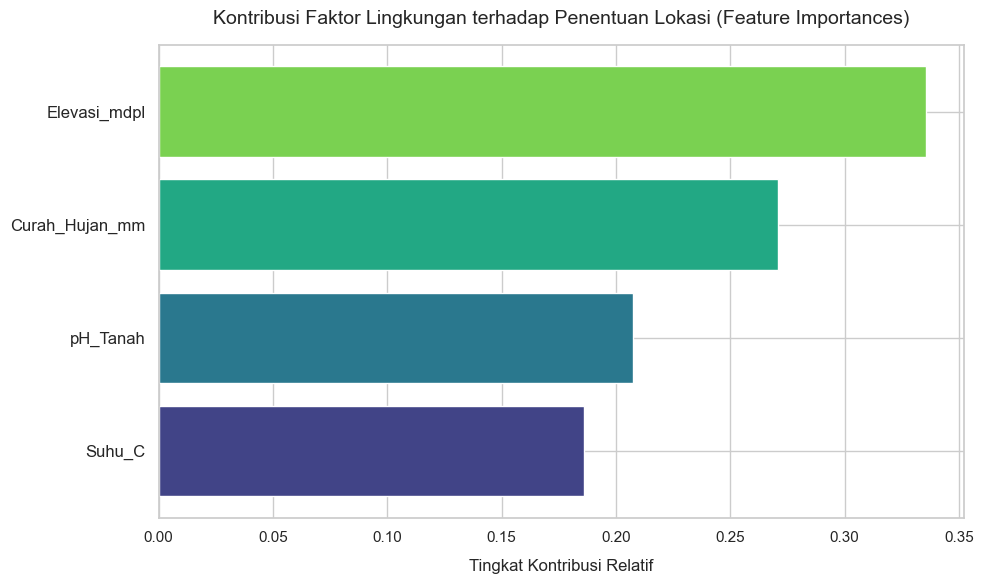

In [12]:
# Ambil bobot kontribusi fitur dari model
importances = rf_model.feature_importances_
indices = np.argsort(importances)

# Plot diagram batang horizontal
plt.figure(figsize=(10, 6))
plt.title('Kontribusi Faktor Lingkungan terhadap Penentuan Lokasi (Feature Importances)', fontsize=14, pad=15)
colors = sns.color_palette("viridis", len(feature_names))
plt.barh(range(len(indices)), importances[indices], align='center', color=colors)
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=12)
plt.xlabel('Tingkat Kontribusi Relatif', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

### B. Simulasi Rekomendasi Varietas Campuran (Hybrid Blended Recommendation)
Alur rekomendasi ini memprediksi kecocokan varietas dengan menggabungkan **60% Keyakinan Geografis Model** (Kecamatan probability distribution) dan **40% Kemiripan Karakteristik Iklim** (Euclidean Distance ternormalisasi Min-Max).

In [13]:
def recommend_varieties(ph, suhu, curah_hujan, elevasi):
    # 1. Siapkan input untuk prediksi
    input_df = pd.DataFrame([[ph, suhu, curah_hujan, elevasi]], 
                            columns=feature_names)
    
    # 2. Prediksi probabilitas tiap kecamatan menggunakan model
    probabilities = rf_model.predict_proba(input_df)[0]
    kec_names = le_kecamatan.classes_
    prob_map = dict(zip(kec_names, probabilities))
    
    best_kec = kec_names[np.argmax(probabilities)]
    confidence = np.max(probabilities)
    
    # 3. Normalisasi Min-Max sebagai acuan jarak similarity
    df_min = df[feature_names].min()
    df_max = df[feature_names].max()
    df_range = (df_max - df_min).replace(0, 1)
    
    normalized_input = (np.array([ph, suhu, curah_hujan, elevasi]) - df_min.values) / df_range.values
    
    # 4. Kelompokkan varietas untuk mendapatkan rata-rata parameter lingkungan pendukung
    variety_env = df.groupby(['Nama_Tanaman', 'Nama_Varietas'])[feature_names].mean().reset_index()
    variety_locs = df.groupby(['Nama_Tanaman', 'Nama_Varietas'])['Kecamatan'].unique().reset_index()
    variety_data = variety_env.merge(variety_locs, on=['Nama_Tanaman', 'Nama_Varietas'])
    
    # 5. Hitung Blended Score
    def calculate_score(row):
        # A. Location Score (bobot lokasi)
        location_score = max(prob_map.get(k, 0) for k in row['Kecamatan'])
        
        # B. Similarity Score (jarak Euclidean)
        variety_features = (row[feature_names].values - df_min.values) / df_range.values
        dist = np.linalg.norm(normalized_input - variety_features)
        similarity_score = 1 / (1 + dist)
        
        # C. Blended Score (60% Bobot Lokasi Model, 40% Kemiripan Iklim)
        return location_score * 0.6 + similarity_score * 0.4
    
    variety_data['Score'] = variety_data.apply(calculate_score, axis=1)
    
    # 6. Pilih varietas dengan nilai kecocokan tertinggi untuk masing-masing tanaman
    recommendations = variety_data.sort_values('Score', ascending=False).groupby('Nama_Tanaman').head(1).reset_index()
    
    print("="*70)
    print("HASIL SIMULASI SISTEM REKOMENDASI VARIETAS HORTIKULTURA")
    print("="*70)
    print(f"Kecamatan Terdekat Teridentifikasi : {best_kec}")
    print(f"Tingkat Keyakinan Geografis Model : {confidence * 100:.2f}%")
    print("="*70)
    print("\nRekomendasi Komoditas Terbaik:")
    for _, row in recommendations.sort_values('Nama_Tanaman').iterrows():
        print(f"- {row['Nama_Tanaman']:<18}: Varietas {row['Nama_Varietas']:<18} (Kecocokan: {row['Score']*100:.2f}%)")
    print("="*70)

# Simulasi input dari user
recommend_varieties(
    ph=6.46, 
    suhu=24.2, 
    curah_hujan=1763, 
    elevasi=255
)

HASIL SIMULASI SISTEM REKOMENDASI VARIETAS HORTIKULTURA
Kecamatan Terdekat Teridentifikasi : Tanah Luas
Tingkat Keyakinan Geografis Model : 72.00%

Rekomendasi Komoditas Terbaik:
- Bayam             : Varietas Maestro            (Kecocokan: 64.49%)
- Cabe Besar        : Varietas Tanjung 2          (Kecocokan: 64.51%)
- Cabe Keriting     : Varietas Lado F1            (Kecocokan: 64.47%)
- Cabe Rawit        : Varietas Taruna             (Kecocokan: 64.47%)
- Kacang Panjang    : Varietas KP-1               (Kecocokan: 64.43%)
- Kangkung          : Varietas Bangkok LP-1       (Kecocokan: 64.61%)
- Ketimun           : Varietas Mercy F1           (Kecocokan: 64.45%)
- Semangka          : Varietas Sugar Baby         (Kecocokan: 64.58%)
- Terung            : Varietas Mustang F1         (Kecocokan: 64.55%)
- Tomat             : Varietas Servo F1           (Kecocokan: 64.55%)
